In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Dataset Overview

The California Housing dataset contains information about housing characteristics in different areas of California.

The target variable is **Price**, which represents the median house value.

The dataset contains numerical features that can be used to predict house prices using Linear Regression.

In [6]:
X = df[["MedInc", "HouseAge", "AveRooms", "AveOccup", "Latitude"]]

y = df["Price"]

print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveOccup  Latitude
0  8.3252      41.0  6.984127  2.555556     37.88
1  8.3014      21.0  6.238137  2.109842     37.86
2  7.2574      52.0  8.288136  2.802260     37.85
3  5.6431      52.0  5.817352  2.547945     37.85
4  3.8462      52.0  6.281853  2.181467     37.85
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


## Feature Selection

For this model, I selected five features that are likely to influence house prices:

- MedInc (Median Income)
- HouseAge
- AveRooms
- AveOccup
- Latitude

These features were chosen because income, property characteristics, occupancy, and location often affect housing prices.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 5)
Testing data: (4128, 5)


## Train-Test Split

The dataset was divided into:

- 80% Training Data
- 20% Testing Data

The training data is used to train the model, while the testing data is used to evaluate how well the model predicts unseen data.

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1.05038269 1.53631311 2.23613307 2.73356232 2.05249505 2.23099918
 2.78786773 2.23379909 2.01824506 4.24437091]


In [10]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.8049810972472425
R² Score: 0.5055020396798211


## Model Evaluation
The Linear Regression model achieved an RMSE of 0.805 and an R² score of 0.51. This means the model explains approximately 50.55% of the variation in house prices based on the selected features. While the model captures a significant portion of the relationship, there is still room for improvement by using additional features or more advanced regression techniques.

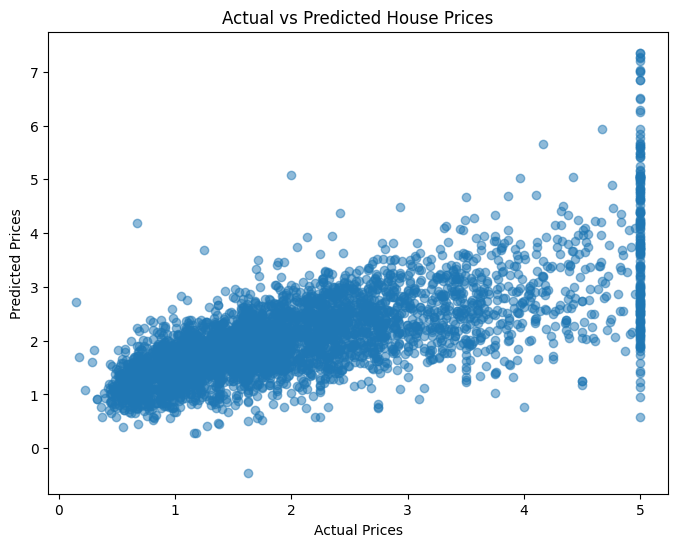

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Model Evaluation

The Linear Regression model was evaluated using RMSE and R² score.

- RMSE (Root Mean Squared Error) measures the average prediction error. Lower RMSE values indicate better model performance.
- R² score measures how well the model explains the variation in house prices. A higher R² value means the model fits the data better.

## What Does the R² Score Mean?

The R² score tells us how well the model explains changes in house prices. A higher R² score means the model's predictions are closer to the actual prices. It does not mean every prediction is perfect, but it shows how much of the price variation is explained by the selected features. This helps us understand how reliable the model is.

## Conclusion

In this task, I built a Linear Regression model using the California Housing dataset. I selected important features, trained the model, and evaluated its performance using RMSE and R² score. The scatter plot comparing actual and predicted prices helped visualize the model's performance. This task improved my understanding of regression and model evaluation.